In [35]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF, AR1, COOKS_D

import pandas as pd
import numpy as np

from scipy.stats import norm, t as t_dist
from statsmodels.graphics.tsaplots import plot_ccf

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 300
A4P = (8.27, 11.69)
A4L = (11.69, 8.27)

In [36]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
rgdp = rgdp.rename(columns={'GDPC1': 'Y'})

pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pce = pce.rename(columns={'PCECC96': 'pce'})

pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
pdi = pdi.rename(columns={'GPDIC1': 'pdi'})

govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
govexp = govexp.rename(columns={'GCEC1': 'govexp'})

odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)
odef = odef.rename(columns={'GDPDEF': 'odef'})

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unat = unat.rename(columns={'NROU': 'u^*'})

unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
unrate = unrate.rename(columns={'LRUN64TTUSQ156S': 'u'})
ugap = pd.DataFrame(
    {
    "ugap": unrate['u'] - unat['u^*'],
    'observation_date': unrate['observation_date']
    }
)

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
gdp_pot = gdp_pot.rename(columns={'GDPPOT': 'Y^*'})
ogap = pd.DataFrame({
    "ogap": np.log(rgdp['Y']) - np.log(gdp_pot['Y^*']),
    'observation_date': rgdp['observation_date']
})

netexp = pd.read_csv('data/fred/NETEXP.csv', **data_kw)
netexp['NETEXP'] = netexp['NETEXP'] / rgdp['Y']
# Interactions
okun = pd.DataFrame({
    "okun": ugap['ugap'] * ogap['ogap'],
    'observation_date': rgdp['observation_date']
})

phillips = pd.DataFrame({
    "phillips": ugap['ugap'] * np.log(odef['odef']).diff(),
    'observation_date': rgdp['observation_date']
})

In [37]:
set = [
    rgdp,
    pce,
    pdi,
    govexp,
    odef,
    # netexp,
    ugap,
    ogap,
    okun,
    phillips,
]
regressors = set[1:]
for df in set:
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
target = np.log(rgdp).diff().dropna()

In [40]:
covid_dates = ("2020-07-01", "2020-04-01")
is_covid = pd.Series(0, index=target.index)
is_covid.loc[covid_dates[1]:covid_dates[0]] = 1

fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    # netexp.diff().loc[target.index],
    ugap.loc[target.index],
    ogap.loc[target.index],
    okun.loc[target.index],
    phillips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index
X = X.loc[t_idx]
y = target.loc[t_idx]
t_idx[-1]

Timestamp('2025-01-01 00:00:00')

In [41]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='n')
fit.error

R2: 0.0877
R2_ADJ: 0.0315
RMSE: 0.0107
MAPE: 1.2859

In [ ]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: True
pval: 3.808064974464287e-14
test_stat: 39.63813856593299
stat_name: RESET Test (F-Statistic)

In [ ]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
{k: v.pval for k, v in t.items()}

{'_const': mpf('0.83556862338041871'),
 'pce': mpf('0.47324343569230454'),
 'pdi': mpf('0.51925286466448162'),
 'govexp': mpf('0.54820838020879092'),
 'ugap': mpf('0.0044078467613288819'),
 'ogap': mpf('0.53070979106916072'),
 'okun': mpf('0.14156546505026779'),
 'phillips': mpf('0.19540215480497003')}

In [ ]:
fit.F_test

reject: False
pval: 0.14261818132696702
test_stat: 1.5612494849364738
stat_name: F Test (F-Statistic)

In [ ]:
VIF(X)

array([1.73207252, 1.61003068, 1.43865623, 1.45072114, 1.84573468,
       2.85814557, 2.75937335])

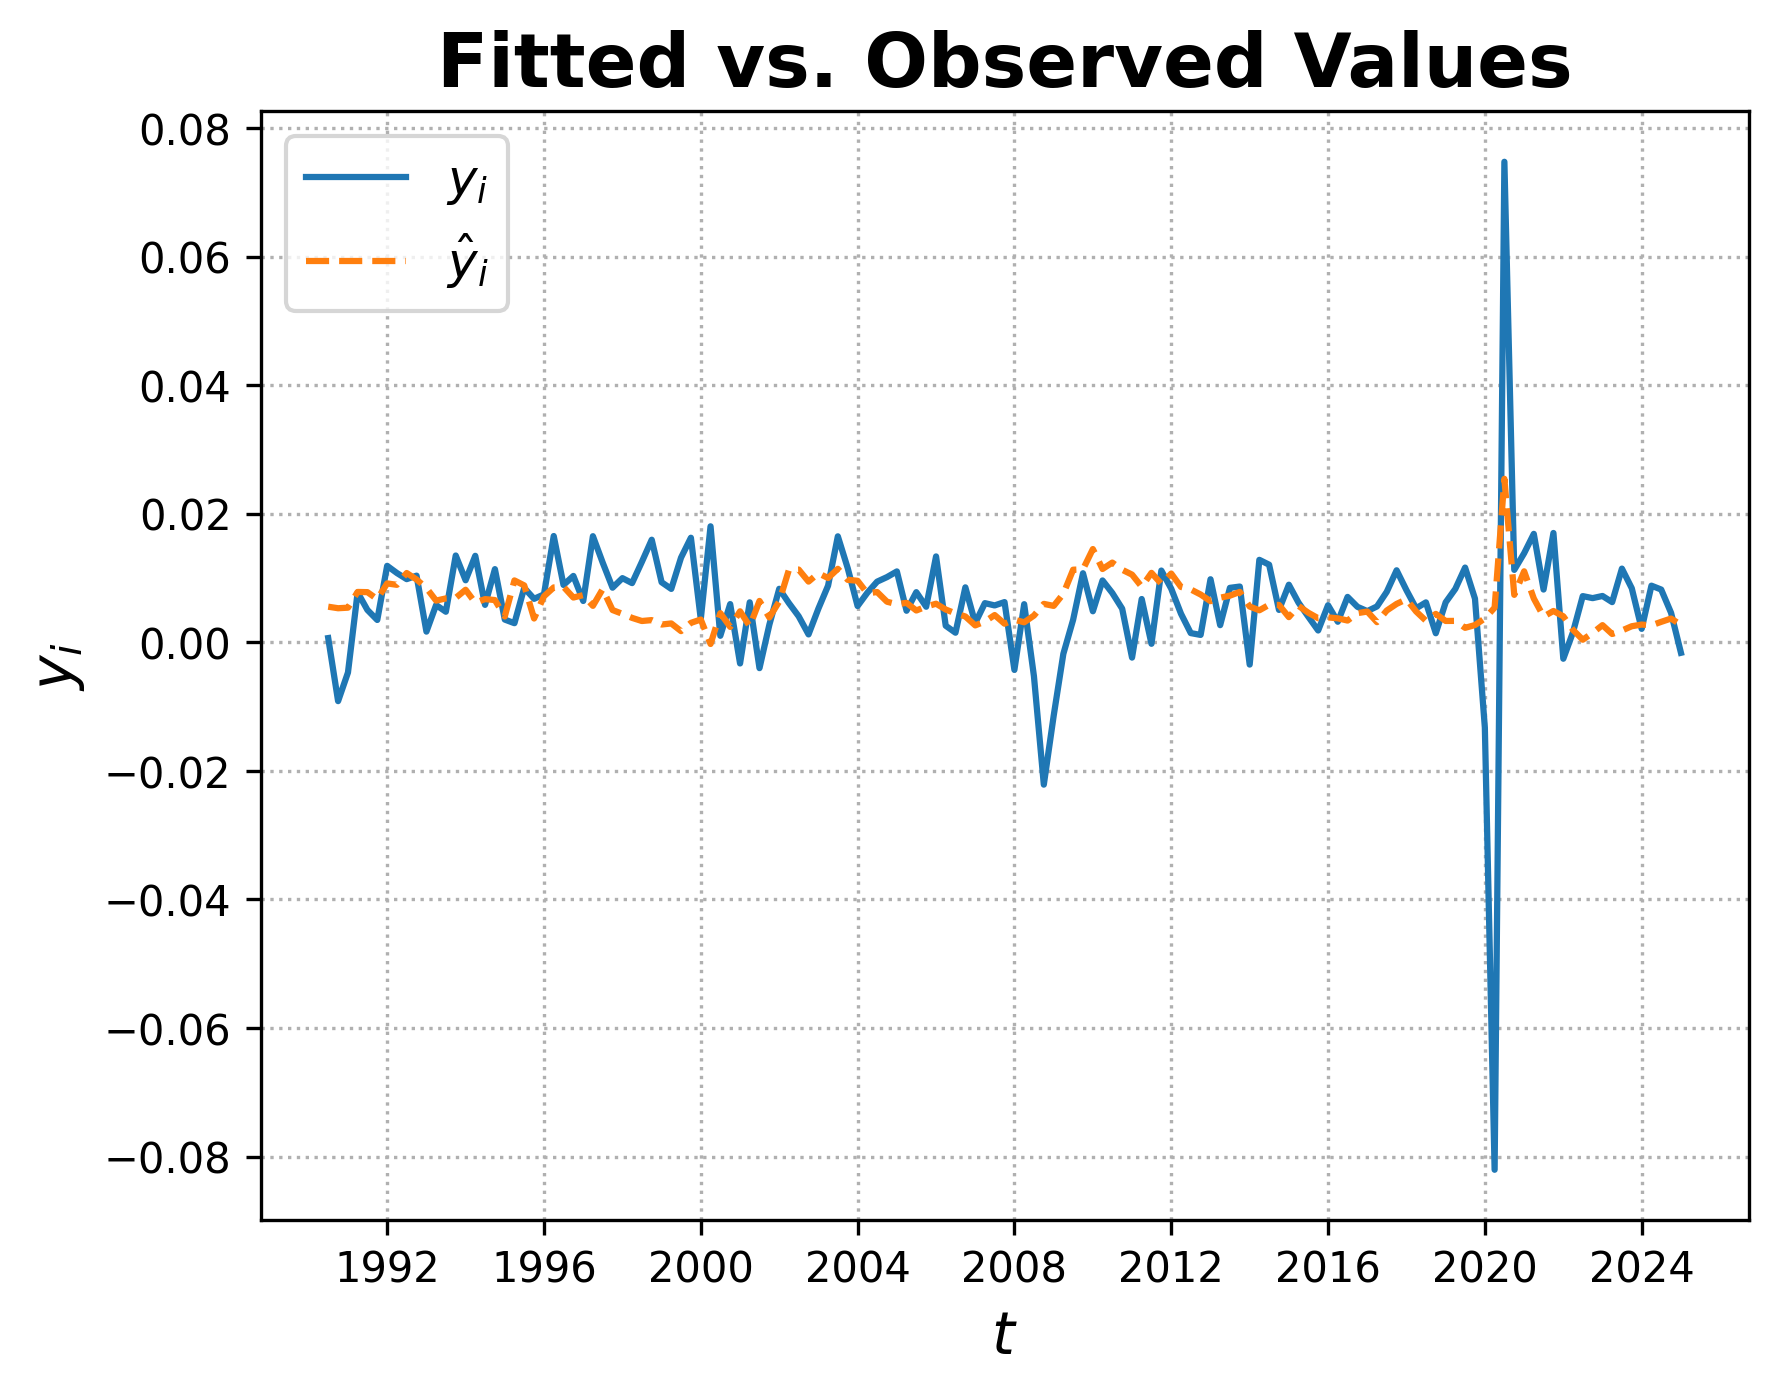

In [ ]:
plt.plot(t_idx, y, label=r"$y_i$")
plt.plot(t_idx, fit.fitted_values, label=r"$\hat{y}_i$", linestyle='--')


plt.title(r"Fitted vs. Observed Values", fontsize=18, weight='bold')
plt.grid(alpha=1, linestyle=":")
plt.tick_params(axis="x", rotation=0, labelsize=10)
plt.tick_params(axis="y", rotation=0, labelsize=10)

plt.ylabel(r"$y_i$", fontsize=14)
plt.xlabel(r"$t$", fontsize=14)

plt.legend(fontsize=12)
plt.savefig('paper2/fig/fit_v_obs.png', dpi=300)
plt.show()


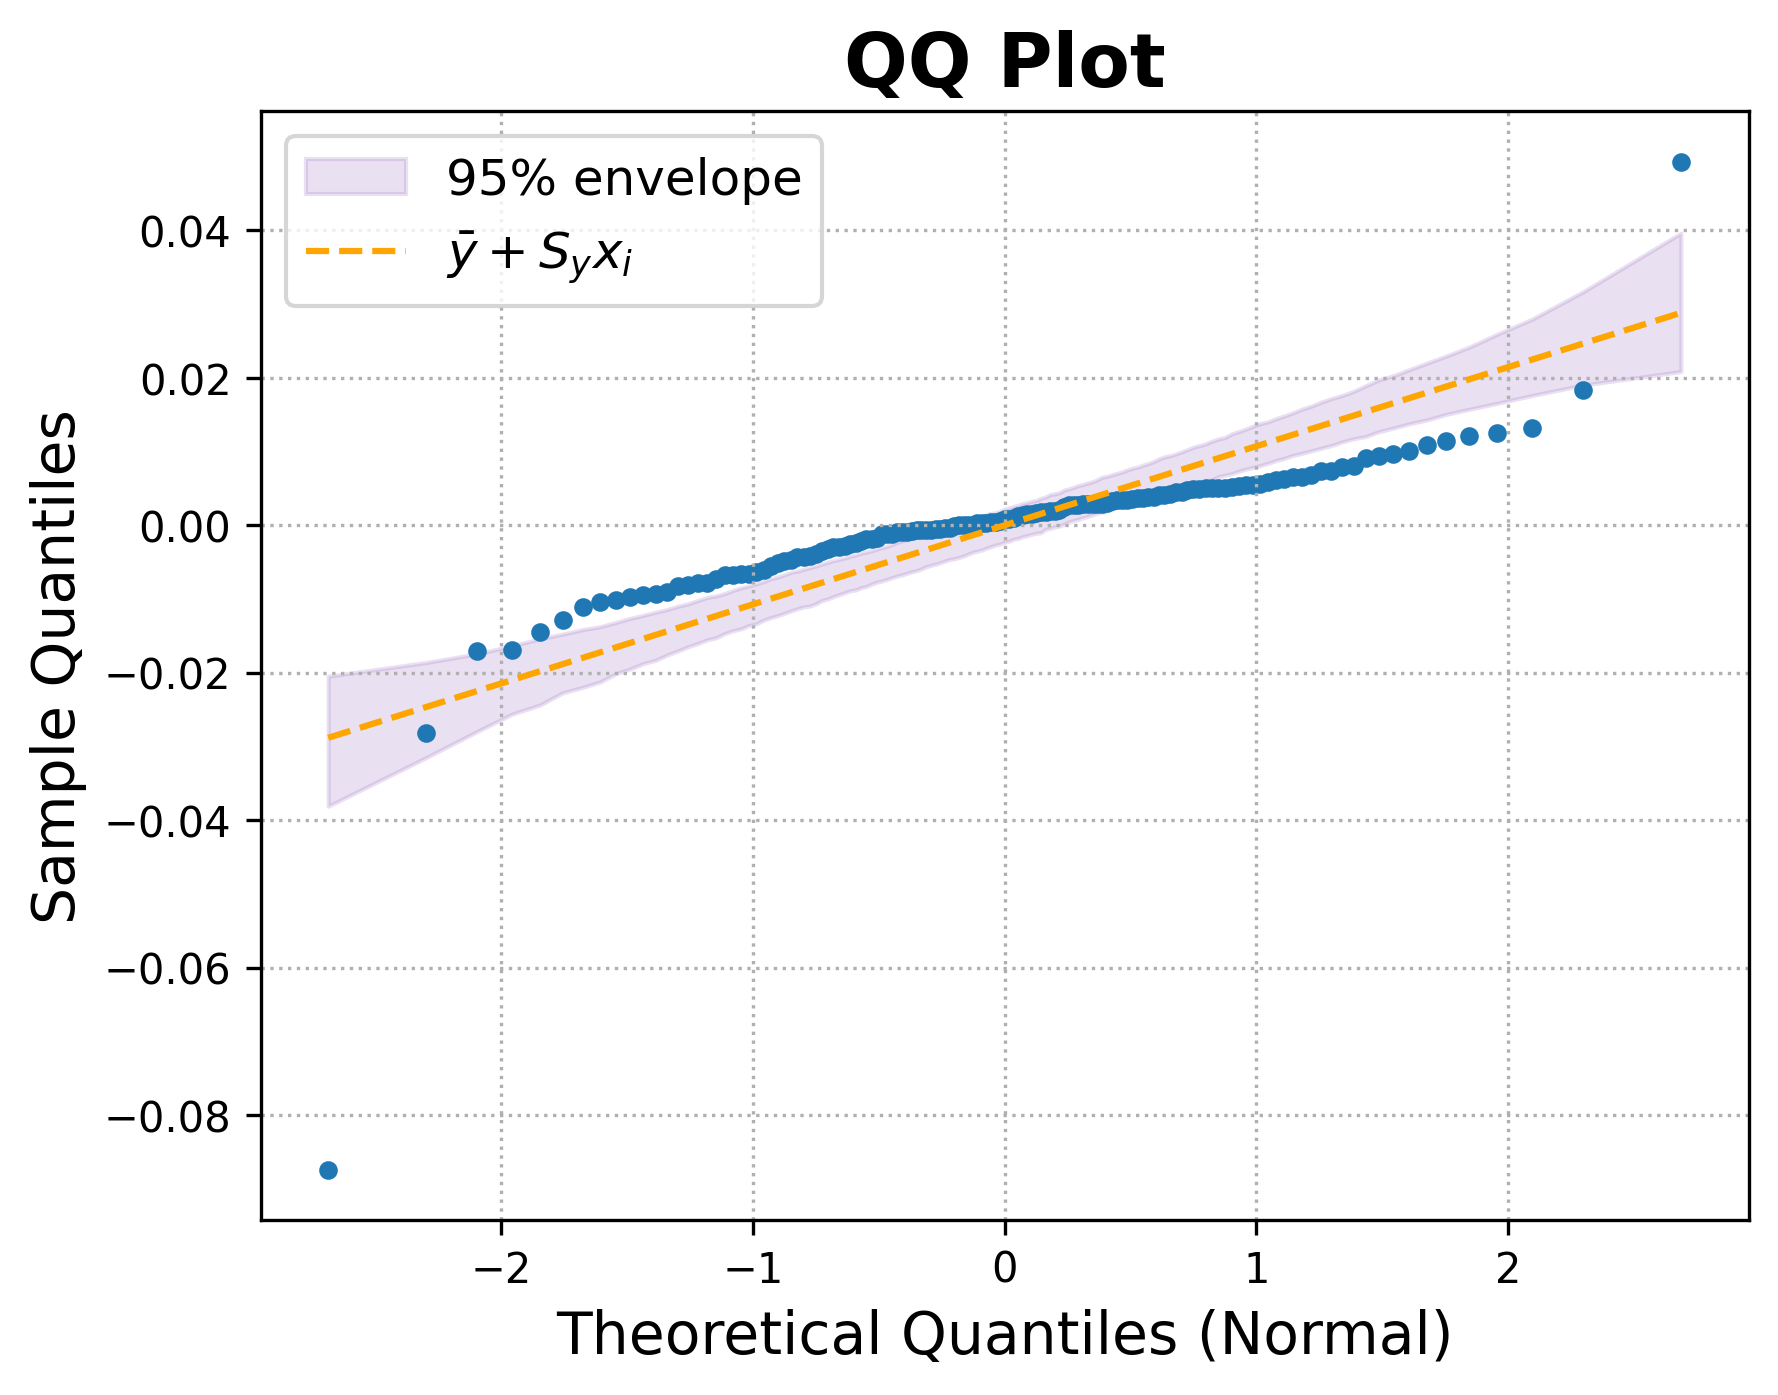

reject: True
pval: 1.89646924817095e-16
test_stat: 0.6618806018139559
stat_name: Shapiro-Wilk Test (Approximated Z-Statistic)

In [ ]:
fit.qq(line='45')
fit.resid_normality

In [ ]:
fit.coefs

array([-0.07328802,  0.0221205 ,  0.09025377,  0.00184064,  0.00579122,
        0.00113591, -0.13887881])

<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
<>:16: SyntaxWarning: invalid escape sequence '\m'
<>:16: SyntaxWarning: invalid escape sequence '\s'
/var/folders/_8/plljqz697vd66bfjdlkc12qm0000gn/T/ipykernel_51770/3992922864.py:16: SyntaxWarning: invalid escape sequence '\m'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
/var/folders/_8/plljqz697vd66bfjdlkc12qm0000gn/T/ipykernel_51770/3992922864.py:16: SyntaxWarning: invalid escape sequence '\s'
  ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")


Text(0.5, 0.98, 'Distributions of Regressors')

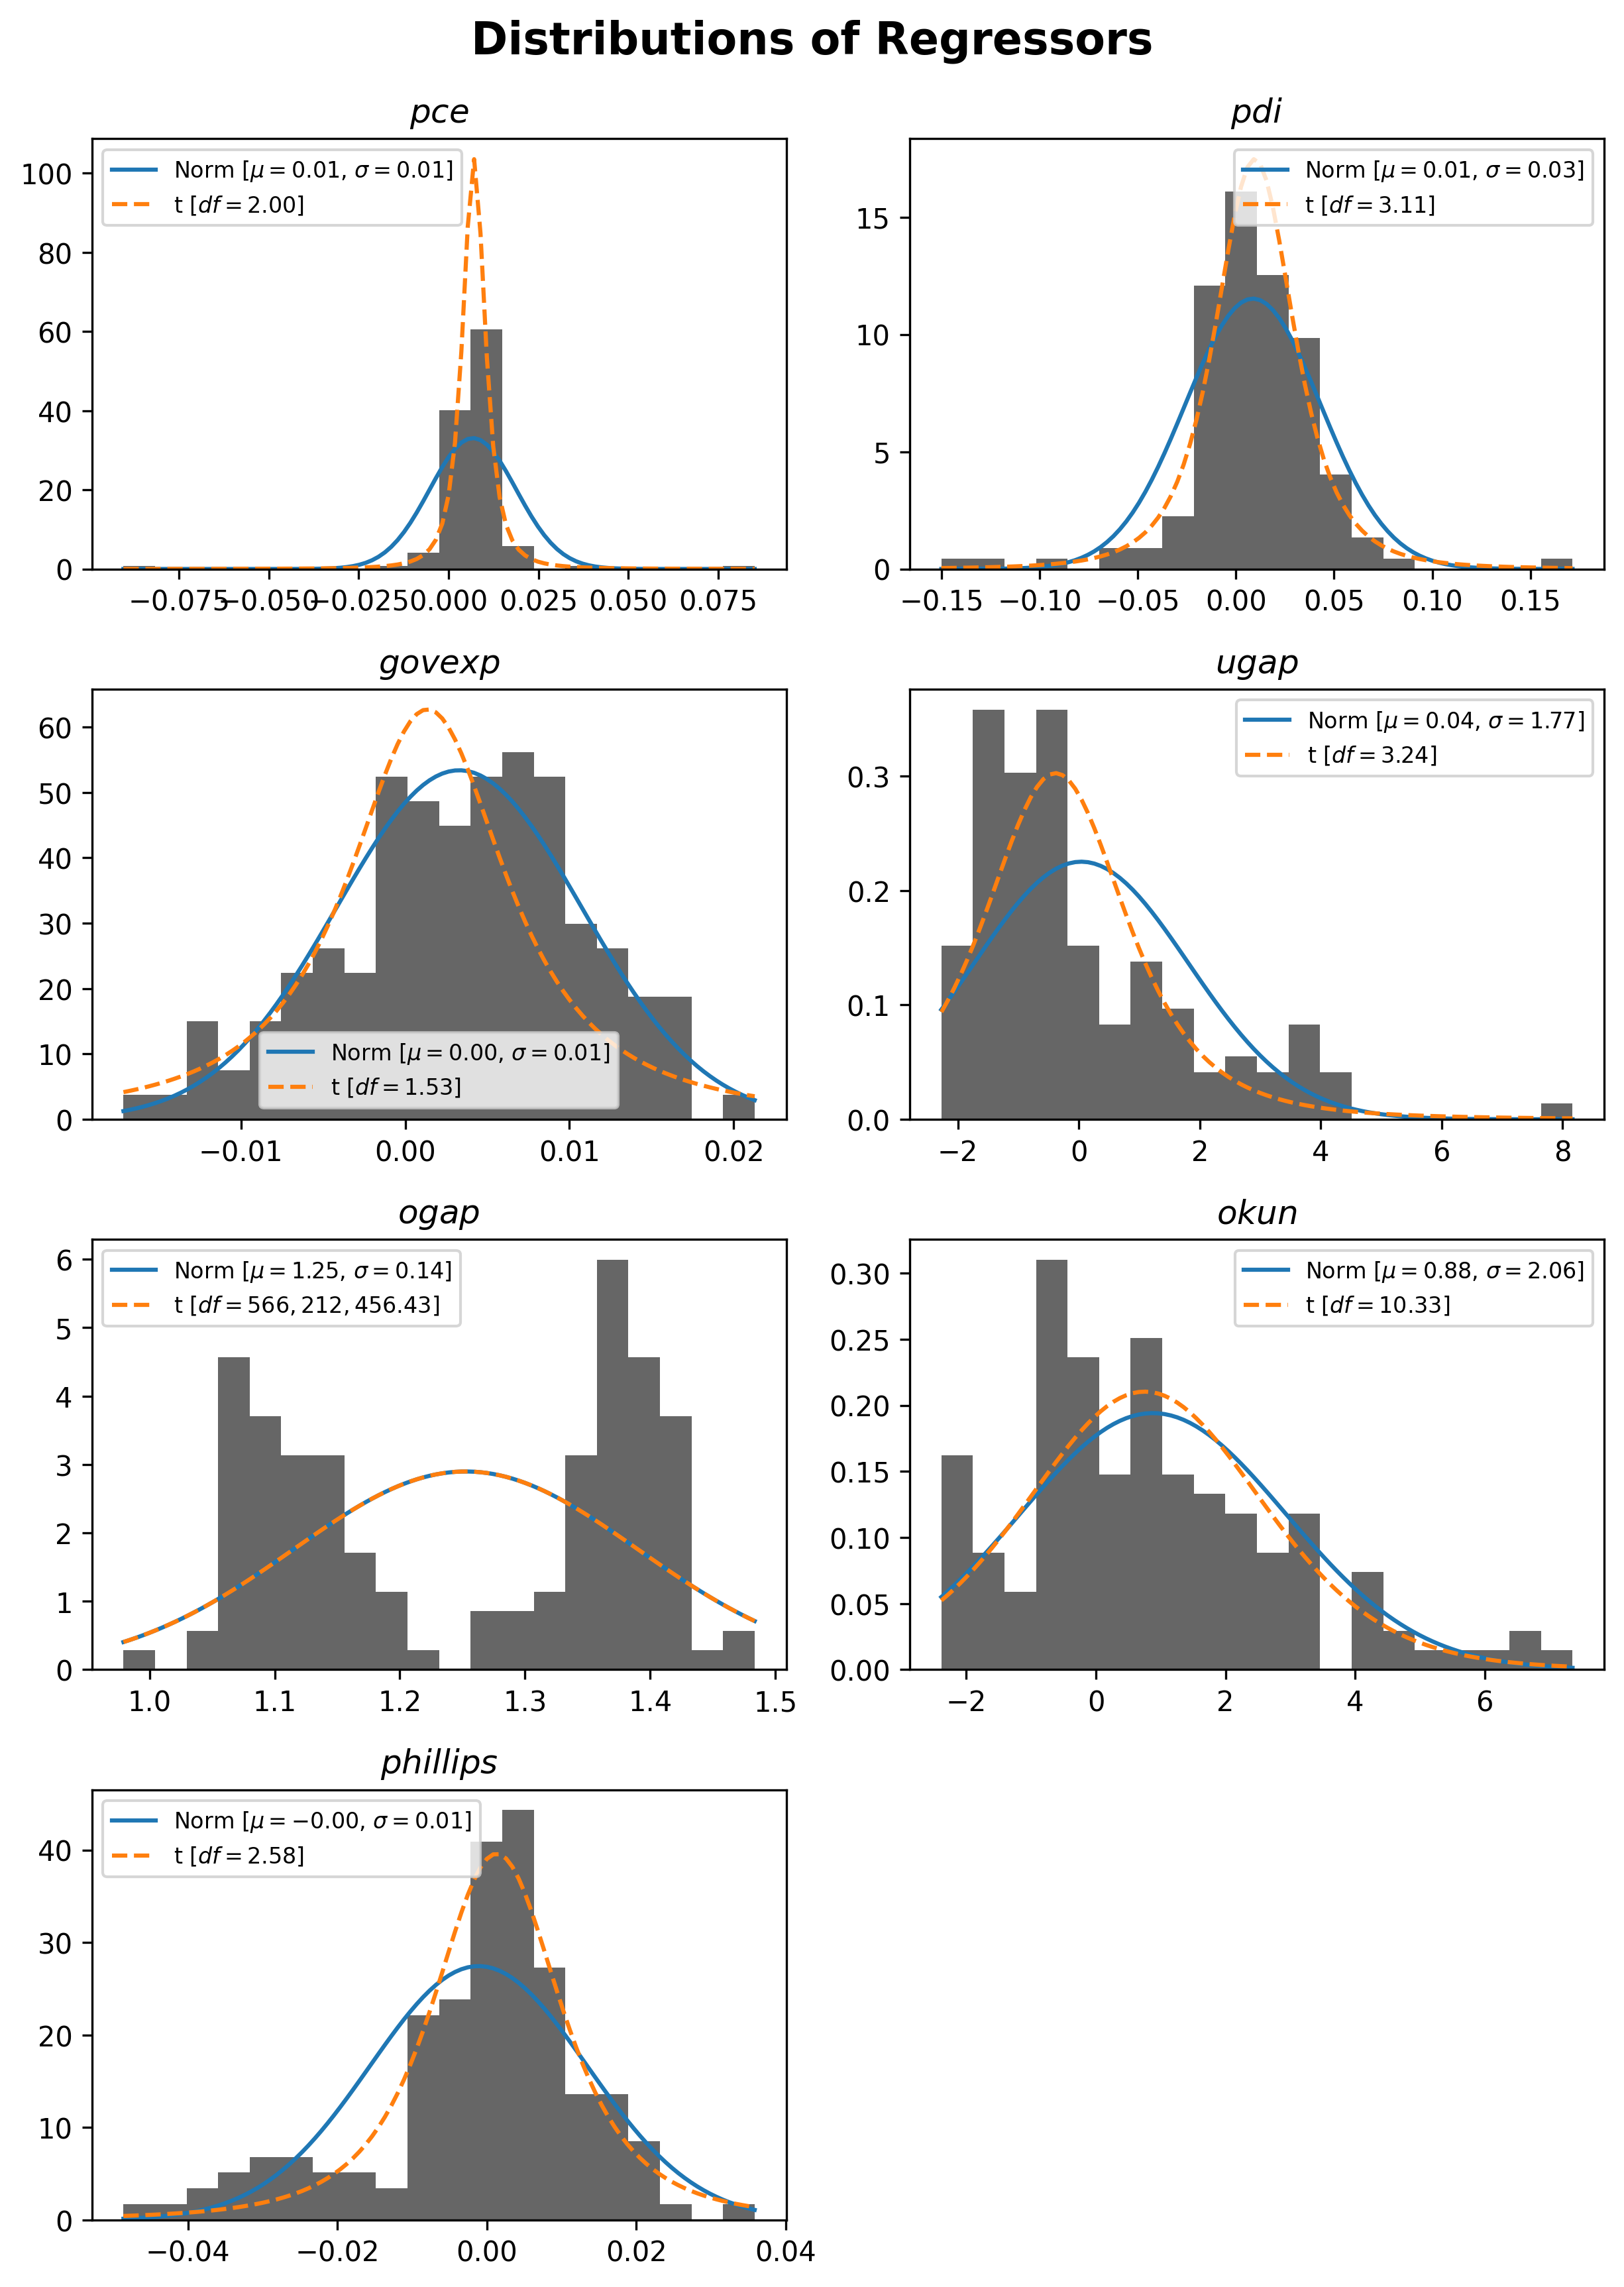

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=A4P)
ax = ax.flatten()
while len(ax) > len(X.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]

for i, v in enumerate(X.columns):
    ax[i].hist(X[v], bins=20, density=True, alpha=0.6, color='black')
    xmin, xmax = X[v].min(), X[v].max()
    x = np.linspace(xmin, xmax, 100)
    mu, std = norm.fit(X[v])
    gaus_fit = norm.pdf(x, mu, std)
    ts = t_dist.fit(X[v])
    t_fit = t_dist.pdf(x, *ts)

    ax[i].plot(x, gaus_fit, label=f"Norm [$\mu={mu:,.2f}$, $\sigma={std:,.2f}$]")
    ax[i].plot(x, t_fit, label=f"t [$df={ts[0]:,.2f}$]", linestyle='--')
    ax[i].set_title(fr"${v}$")
    ax[i].legend(fontsize=8, loc='best')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("Distributions of Regressors", fontsize=16, weight='bold')

In [ ]:
target

,Y
observation_date,
1990-04-01,0.003623
1990-07-01,0.000666
1990-10-01,-0.009146
1991-01-01,-0.004690
1991-04-01,0.007767
...,...
2024-01-01,0.002096
2024-04-01,0.008816
2024-07-01,0.008214


pce: -0.2211
pdi: -0.1618
govexp: 0.0726
ugap: 0.7766
ogap: -0.7236
okun: -0.0135
phillips: -0.0032


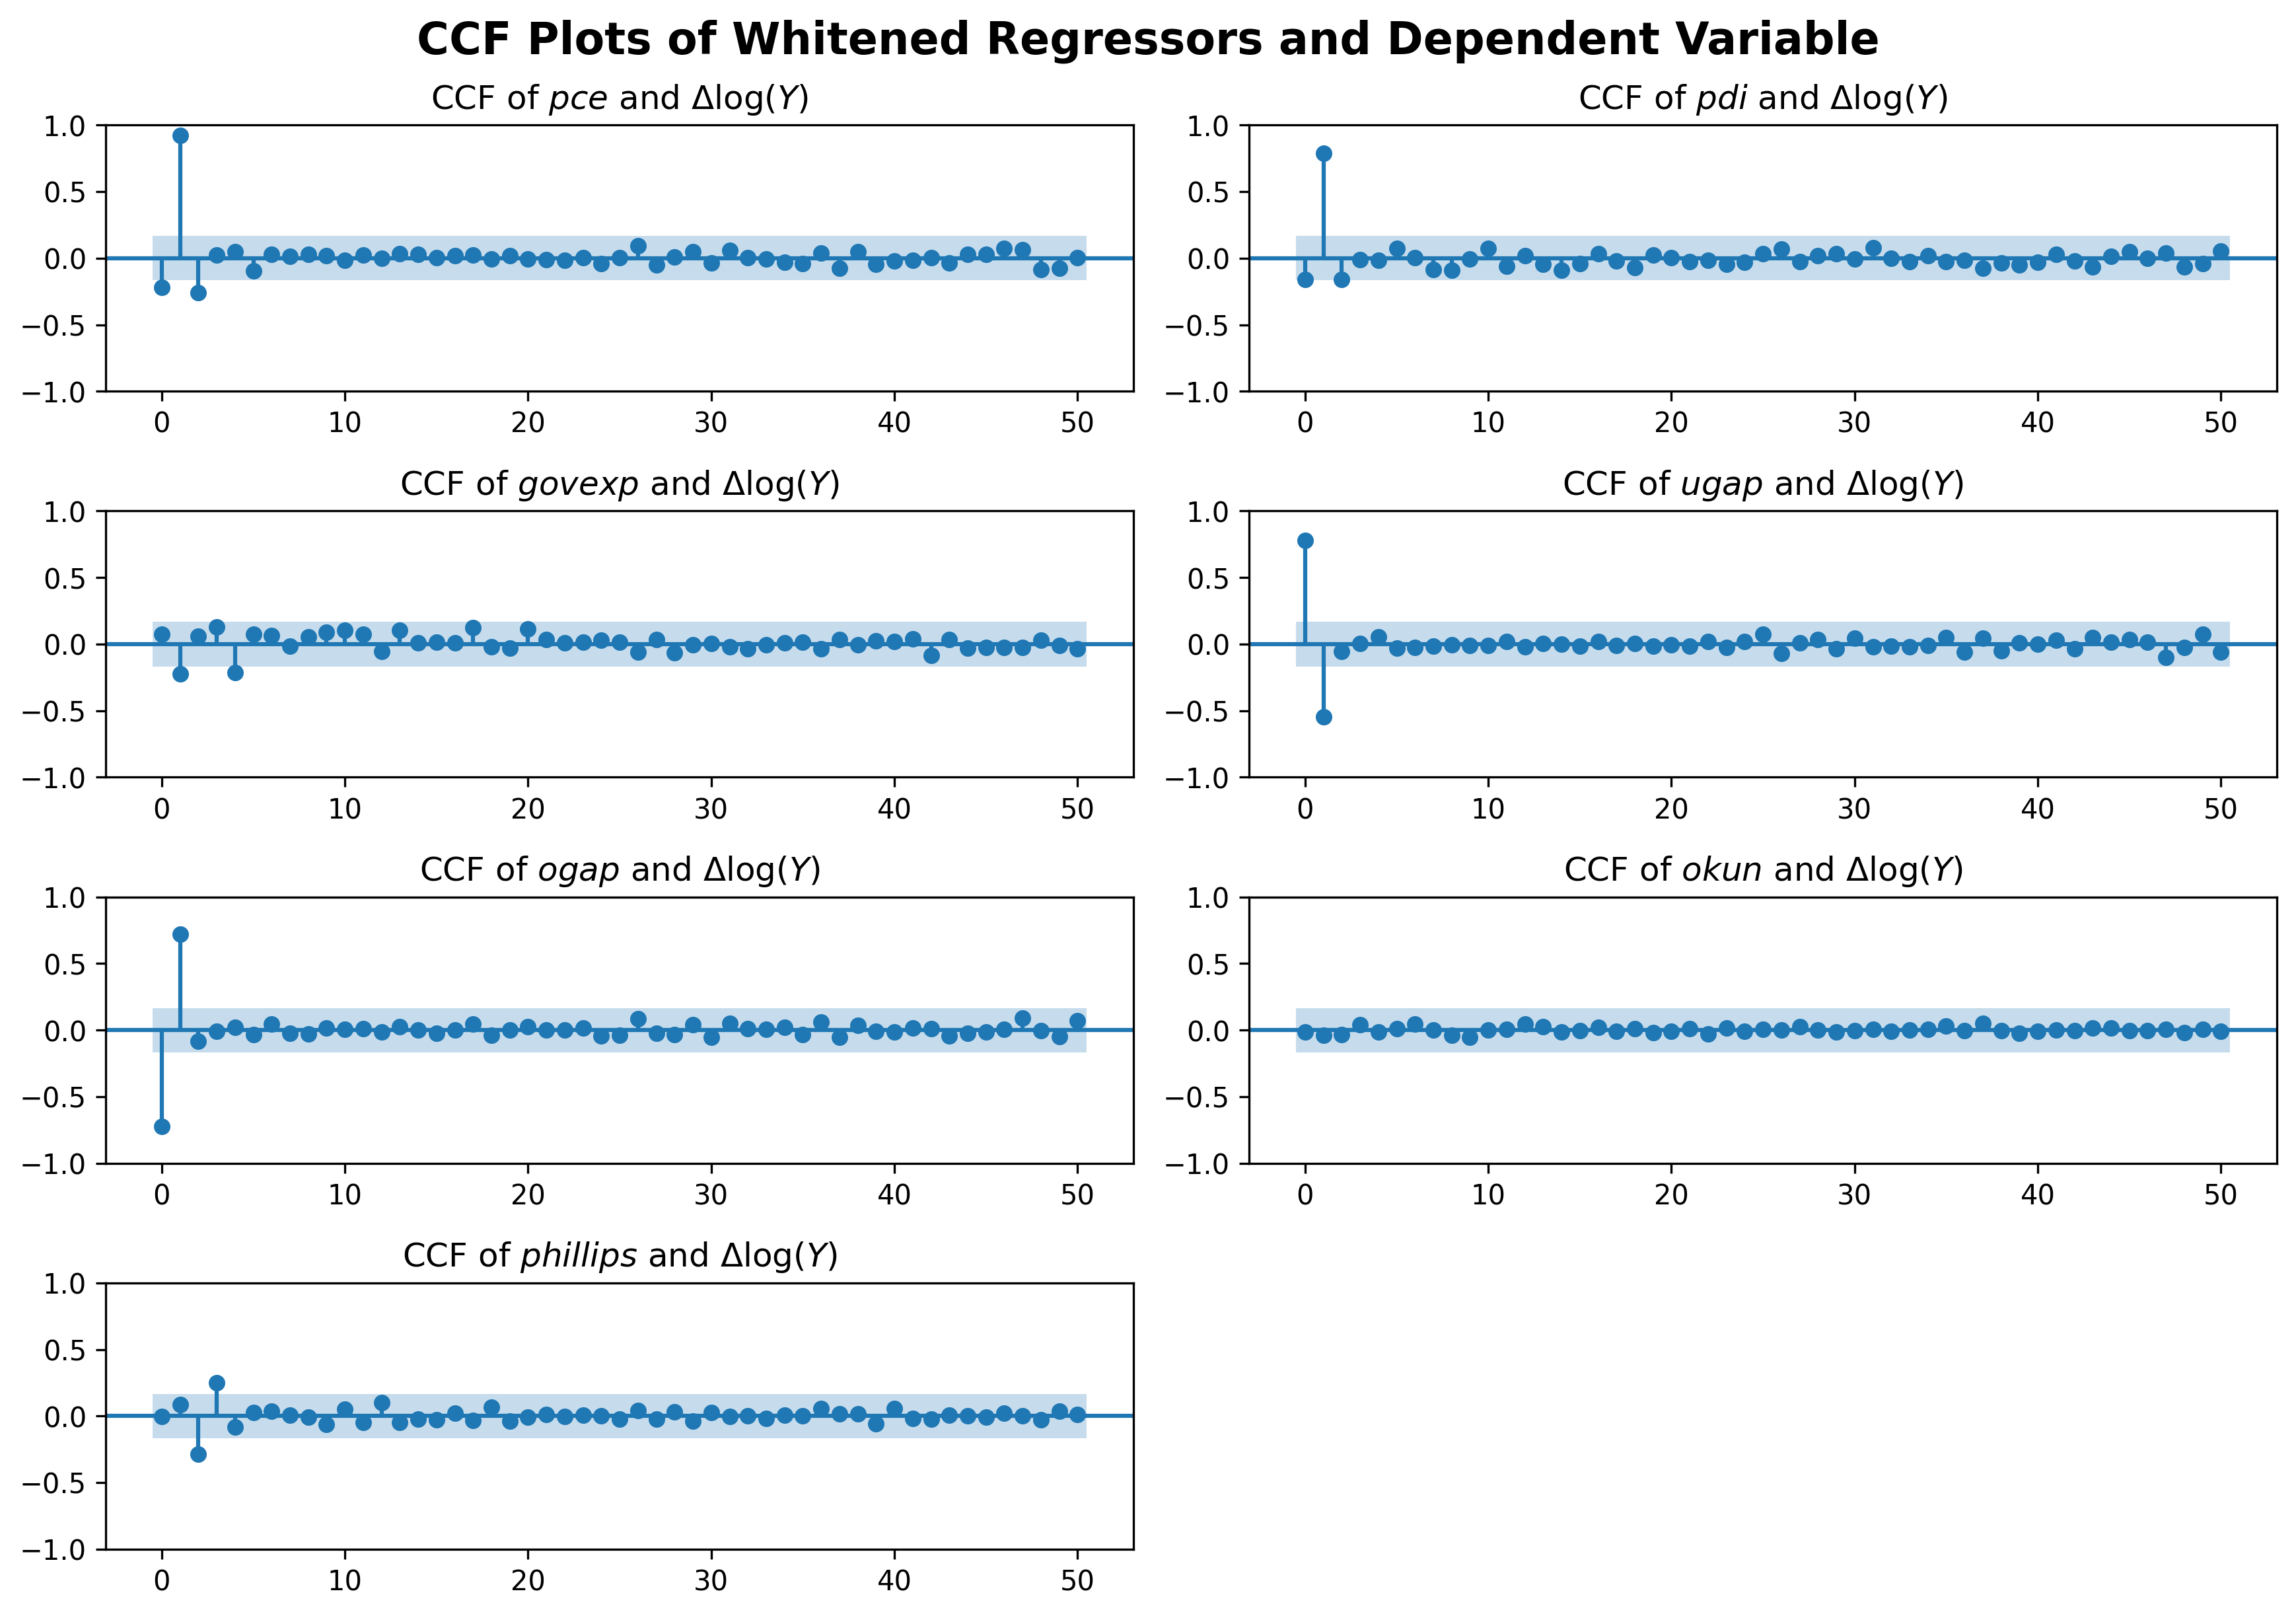

In [ ]:
fig, ax = plt.subplots(4, 2, figsize=A4L)
ax = ax.flatten()
while len(ax) > len(X.columns):
    fig.delaxes(ax[-1])
    ax = ax[:-1]
    
for i, v in enumerate(X.columns):
    coef = AR1(X[v].values, 'n')
    resid = X[v].values[1:] - coef * X[v].values[:-1]
    target = y.values[1:] - coef * y.values[:-1]
    print(f"{v}: {np.corrcoef(resid.flatten(), target.flatten())[0,1]:.4f}")
    plot_ccf(resid, target, lags=50, ax=ax[i], title=fr"CCF of ${v}$ and $\Delta \log(Y)$")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.suptitle("CCF Plots of Whitened Regressors and Dependent Variable", fontsize=16, weight='bold')
fig.savefig('paper2/fig/ccf.png')
    


In [ ]:
fit.XT_e

np.float64(-8.791264157620438e-14)

In [ ]:
D, *_ = COOKS_D(
    X=X,
    y=y.values.flatten(),
    intercept=True,
    plot=False
)

pd.Series(D, index=t_idx).sort_values(ascending=False)

observation_date
2020-07-01    8.483721e+00
2020-04-01    8.011641e-01
2009-01-01    3.289772e-02
2000-04-01    2.930991e-02
2020-10-01    2.240642e-02
                  ...     
2000-01-01    3.320851e-07
1991-04-01    2.515940e-07
2004-04-01    2.426617e-07
2017-01-01    1.257310e-07
2005-10-01    7.342438e-09
Length: 139, dtype: float64